In [ ]:
""" pr10 Data Visualization III
Download the Iris flower dataset or any other dataset into a DataFrame. (e.g.,
https://archive.ics.uci.edu/ml/datasets/Iris ). Scan the dataset and give the inference as:
1. List down the features and their types (e.g., numeric, nominal) available in the dataset.
2. Create a histogram for each feature in the dataset to illustrate the feature distributions.
3. Create a boxplot for each feature in the dataset.
4. Compare distributions and identify outliers."""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dsbdal.csv")

df.columns = df.columns.str.strip().str.lower()

print("Iris dataset loaded successfully")
df.head()

Iris dataset loaded successfully


,id,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species
0,1.0,5.1,3.5,1.4,0.2,Iris-setosa
1,2.0,4.9,3.0,1.4,0.2,Iris-setosa
2,3.0,4.7,3.2,1.3,0.2,Iris-setosa
3,4.0,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Dataset Information:")
df.info()

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             143 non-null    float64
 1   sepallengthcm  145 non-null    float64
 2   sepalwidthcm   146 non-null    float64
 3   petallengthcm  145 non-null    float64
 4   petalwidthcm   147 non-null    float64
 5   species        143 non-null    object 
dtypes: float64(5), object(1)
memory usage: 7.0+ KB

Shape of Dataset:
(147, 6)

Column Names:
Index(['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'],
      dtype='object')


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id               4
sepallengthcm    2
sepalwidthcm     1
petallengthcm    2
petalwidthcm     0
species          4
dtype: int64


In [5]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical / Nominal Features:")
print(categorical_features)

Numeric Features:
['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm']

Categorical / Nominal Features:
['species']


In [6]:
feature_types = []

for col in df.columns:
    if col in numeric_features:
        feature_types.append([col, "Numeric"])
    else:
        feature_types.append([col, "Nominal / Categorical"])

feature_table = pd.DataFrame(feature_types, columns=["Feature Name", "Feature Type"])

feature_table

,Feature Name,Feature Type
0,id,Numeric
1,sepallengthcm,Numeric
2,sepalwidthcm,Numeric
3,petallengthcm,Numeric
4,petalwidthcm,Numeric
5,species,Nominal / Categorical


In [7]:
if "id" in numeric_features:
    numeric_features.remove("id")

print("Final numeric features for visualization:")
print(numeric_features)

Final numeric features for visualization:
['sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm']


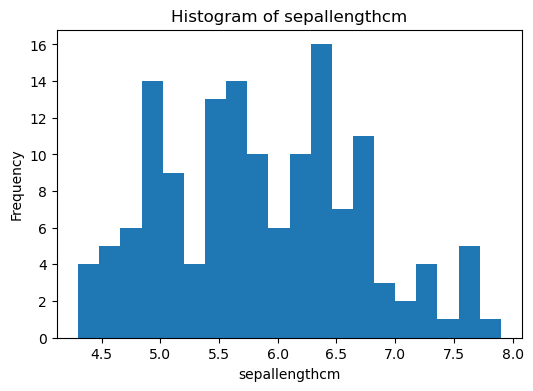

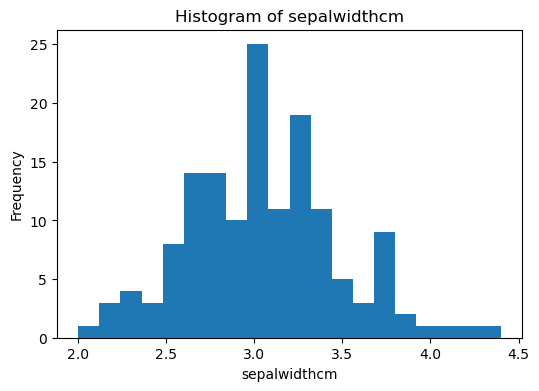

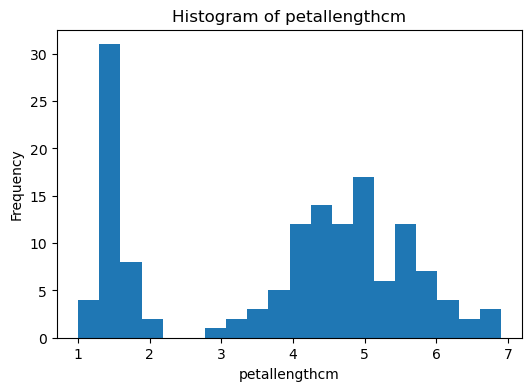

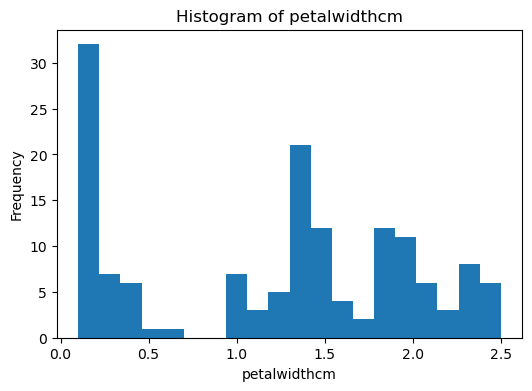

In [8]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    
    plt.hist(df[col], bins=20)
    
    plt.title("Histogram of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

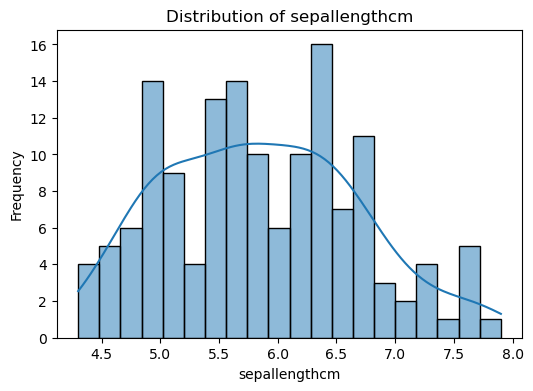

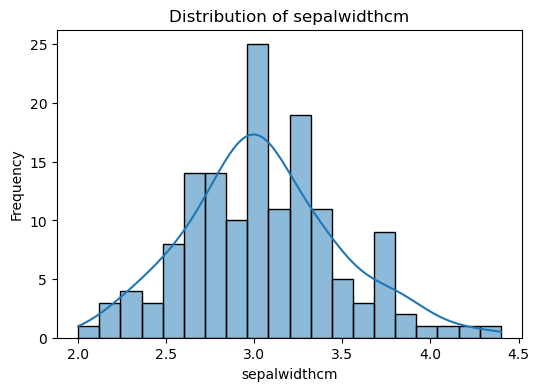

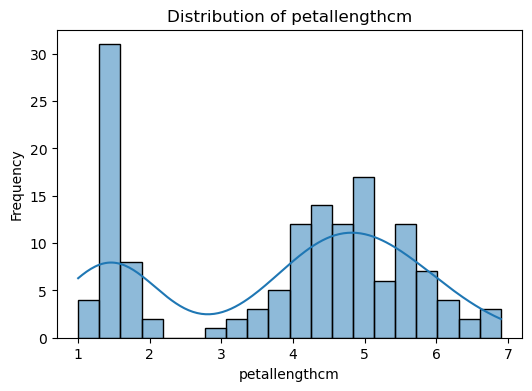

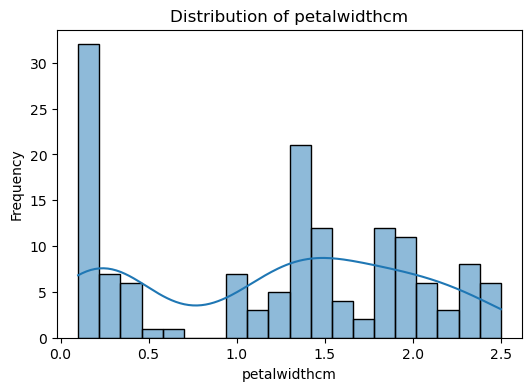

In [9]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    
    sns.histplot(df[col], bins=20, kde=True)
    
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

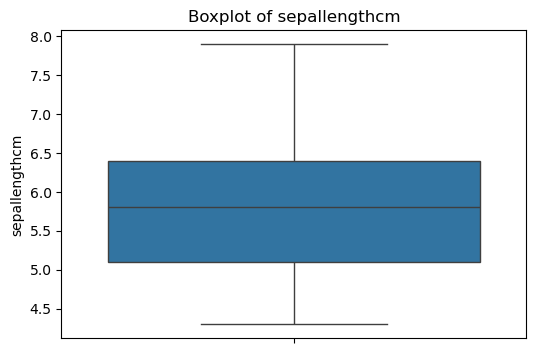

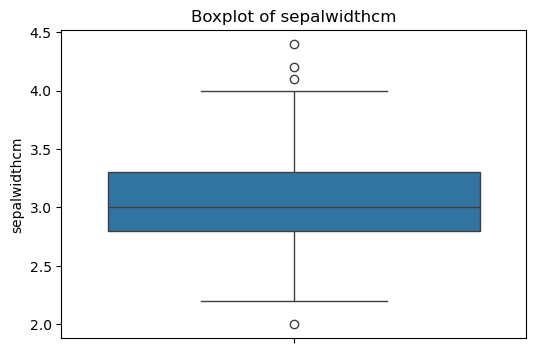

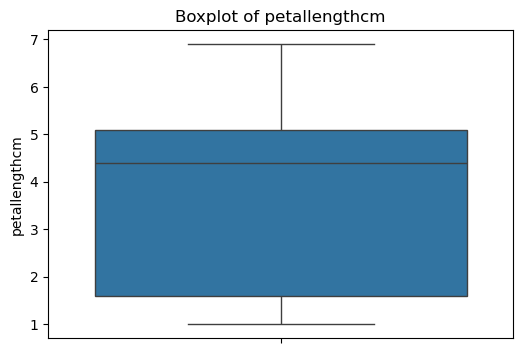

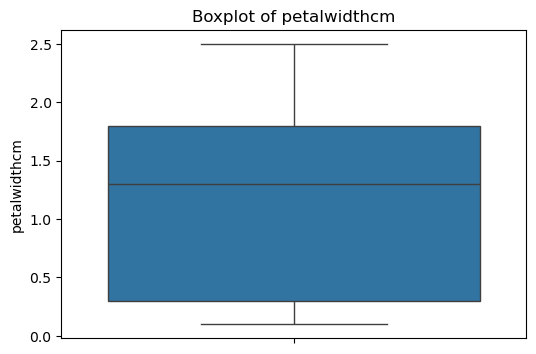

In [10]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(y=df[col])
    
    plt.title("Boxplot of " + col)
    plt.ylabel(col)
    
    plt.show()

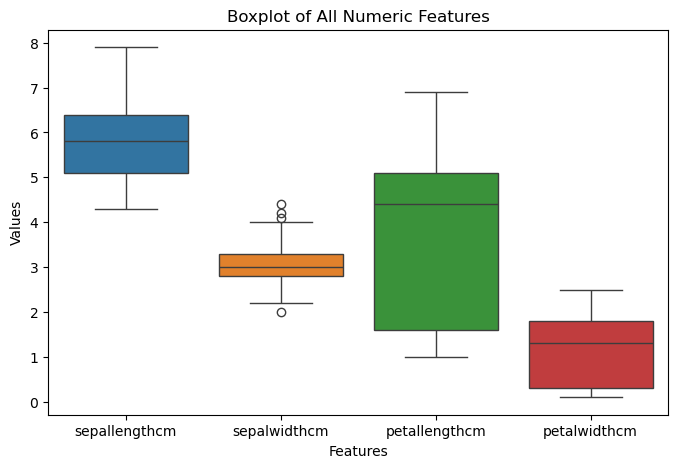

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df[numeric_features])

plt.title("Boxplot of All Numeric Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [12]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_limit) | (data[column] > upper_limit)]
    
    return outliers

In [13]:
for col in numeric_features:
    outliers = detect_outliers_iqr(df, col)
    
    print("\nFeature:", col)
    print("Number of outliers:", len(outliers))
    
    if len(outliers) > 0:
        print(outliers[[col]])
    else:
        print("No outliers found")


Feature: sepallengthcm
Number of outliers: 0
No outliers found

Feature: sepalwidthcm
Number of outliers: 4
    sepalwidthcm
15           4.4
28           4.1
29           4.2
56           2.0

Feature: petallengthcm
Number of outliers: 0
No outliers found

Feature: petalwidthcm
Number of outliers: 0
No outliers found


In [14]:
print("Statistical summary of numeric features:")

df[numeric_features].describe()

Statistical summary of numeric features:


,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm
count,145.000000,146.000000,145.000000,147.000000
mean,5.859310,3.048630,3.835172,1.217687
std,0.825336,0.436954,1.744775,0.758938
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000
